In [3]:
import warnings
from sklearn import metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', size=14)
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn import metrics
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

In [4]:
data = pd.read_csv('wisc_bc_data.csv')

In [5]:
df = data.copy()

In [6]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,points_worst,symmetry_worst,dimension_worst
0,87139402,B,12.32,12.39,78.85,464.1,0.10280,0.06981,0.03987,0.03700,...,13.50,15.64,86.97,549.1,0.1385,0.1266,0.12420,0.09391,0.2827,0.06771
1,8910251,B,10.60,18.95,69.28,346.4,0.09688,0.11470,0.06387,0.02642,...,11.88,22.94,78.28,424.8,0.1213,0.2515,0.19160,0.07926,0.2940,0.07587
2,905520,B,11.04,16.83,70.92,373.2,0.10770,0.07804,0.03046,0.02480,...,12.41,26.44,79.93,471.4,0.1369,0.1482,0.10670,0.07431,0.2998,0.07881
3,868871,B,11.28,13.39,73.00,384.8,0.11640,0.11360,0.04635,0.04796,...,11.92,15.77,76.53,434.0,0.1367,0.1822,0.08669,0.08611,0.2102,0.06784
4,9012568,B,15.19,13.21,97.65,711.8,0.07963,0.06934,0.03393,0.02657,...,16.20,15.73,104.50,819.1,0.1126,0.1737,0.13620,0.08178,0.2487,0.06766


In [7]:
data.isnull().sum()

id                   0
diagnosis            0
radius_mean          0
texture_mean         0
perimeter_mean       0
area_mean            0
smoothness_mean      0
compactness_mean     0
concavity_mean       0
points_mean          0
symmetry_mean        0
dimension_mean       0
radius_se            0
texture_se           0
perimeter_se         0
area_se              0
smoothness_se        0
compactness_se       0
concavity_se         0
points_se            0
symmetry_se          0
dimension_se         0
radius_worst         0
texture_worst        0
perimeter_worst      0
area_worst           0
smoothness_worst     0
compactness_worst    0
concavity_worst      0
points_worst         0
symmetry_worst       0
dimension_worst      0
dtype: int64

In [8]:
data.isna().sum()

id                   0
diagnosis            0
radius_mean          0
texture_mean         0
perimeter_mean       0
area_mean            0
smoothness_mean      0
compactness_mean     0
concavity_mean       0
points_mean          0
symmetry_mean        0
dimension_mean       0
radius_se            0
texture_se           0
perimeter_se         0
area_se              0
smoothness_se        0
compactness_se       0
concavity_se         0
points_se            0
symmetry_se          0
dimension_se         0
radius_worst         0
texture_worst        0
perimeter_worst      0
area_worst           0
smoothness_worst     0
compactness_worst    0
concavity_worst      0
points_worst         0
symmetry_worst       0
dimension_worst      0
dtype: int64

In [9]:
data.isin([0]).sum()

id                    0
diagnosis             0
radius_mean           0
texture_mean          0
perimeter_mean        0
area_mean             0
smoothness_mean       0
compactness_mean      0
concavity_mean       13
points_mean          13
symmetry_mean         0
dimension_mean        0
radius_se             0
texture_se            0
perimeter_se          0
area_se               0
smoothness_se         0
compactness_se        0
concavity_se         13
points_se            13
symmetry_se           0
dimension_se          0
radius_worst          0
texture_worst         0
perimeter_worst       0
area_worst            0
smoothness_worst      0
compactness_worst     0
concavity_worst      13
points_worst         13
symmetry_worst        0
dimension_worst       0
dtype: int64

In [10]:
cols = ['concavity_mean','points_mean','concavity_se','points_se','concavity_worst','points_worst']

In [11]:
data[cols] = data[cols].replace(0, np.nan)

In [12]:
data[cols] = data[cols].fillna(data[cols].mean())

In [13]:
data.isin([0]).sum()

id                   0
diagnosis            0
radius_mean          0
texture_mean         0
perimeter_mean       0
area_mean            0
smoothness_mean      0
compactness_mean     0
concavity_mean       0
points_mean          0
symmetry_mean        0
dimension_mean       0
radius_se            0
texture_se           0
perimeter_se         0
area_se              0
smoothness_se        0
compactness_se       0
concavity_se         0
points_se            0
symmetry_se          0
dimension_se         0
radius_worst         0
texture_worst        0
perimeter_worst      0
area_worst           0
smoothness_worst     0
compactness_worst    0
concavity_worst      0
points_worst         0
symmetry_worst       0
dimension_worst      0
dtype: int64

### Bivariate analysis

In [14]:
data['diagnosis']=data['diagnosis'].map({'B':0,'M':1})

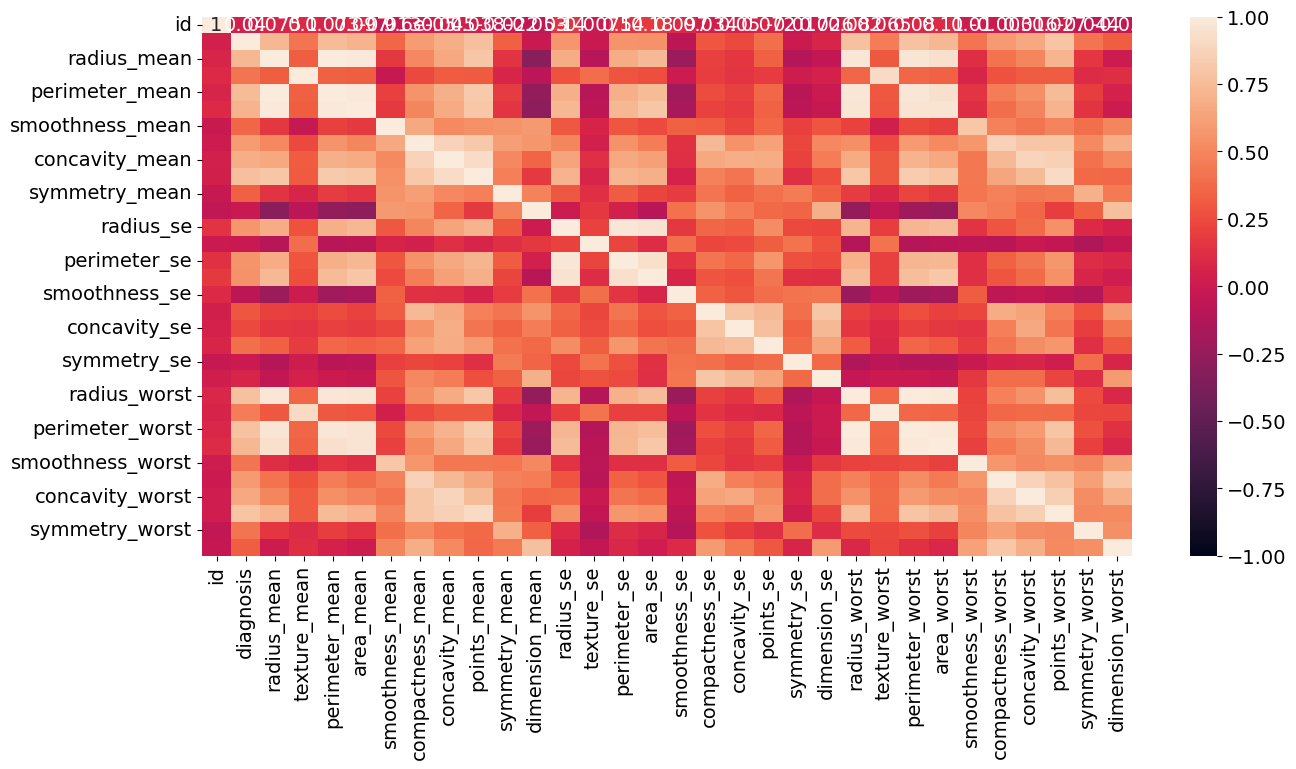

In [15]:
plt.figure(figsize=(15,7))
sns.heatmap(data.corr(), vmin=-1, vmax=1, annot=True)
plt.show();

In [16]:
data['diagnosis'].value_counts(1)*100

diagnosis
0    62.741652
1    37.258348
Name: proportion, dtype: float64

In [17]:
vif_series = pd.Series([variance_inflation_factor(data.values,i) for i in range(data.shape[1])],
                       index=data.columns,
                       dtype=float)
vif_series

id                       1.164264
diagnosis                6.793683
radius_mean          63008.911373
texture_mean           254.551759
perimeter_mean       57506.430247
area_mean             1300.657834
smoothness_mean        391.144952
compactness_mean       200.520083
concavity_mean         160.222178
points_mean            155.734122
symmetry_mean          184.818390
dimension_mean         637.166331
radius_se              237.886860
texture_se              25.923662
perimeter_se           212.153807
area_se                 74.488583
smoothness_se           26.360455
compactness_se          45.144942
concavity_se            34.065892
points_se               60.456146
symmetry_se             37.088667
dimension_se            27.645319
radius_worst          9964.048597
texture_worst          352.986657
perimeter_worst       4494.313739
area_worst            1166.700346
smoothness_worst       370.087795
compactness_worst      132.627592
concavity_worst         85.443070
points_worst  

In [18]:
data1 = data.drop(columns=['radius_mean',
                          'perimeter_mean',
                          'radius_worst',
                          'perimeter_worst',
                          'texture_mean',
                          'smoothness_mean',
                          'dimension_mean'],axis=1)

In [19]:
vif_series1 = pd.Series([variance_inflation_factor(data1.values,i) for i in range(data1.shape[1])],
                       index=data1.columns,
                       dtype=float)
vif_series1

id                     1.161763
diagnosis              5.897019
area_mean             73.533426
compactness_mean      97.858381
concavity_mean       139.906905
points_mean          135.340556
symmetry_mean        152.085648
radius_se            112.034412
texture_se            18.288725
perimeter_se          90.759728
area_se               36.971946
smoothness_se         21.895390
compactness_se        42.173789
concavity_se          31.469835
points_se             50.919387
symmetry_se           31.527506
dimension_se          24.330513
texture_worst         47.351542
area_worst            73.895210
smoothness_worst     145.511764
compactness_worst    101.036011
concavity_worst       82.431854
points_worst         122.350225
symmetry_worst       188.174581
dimension_worst      173.677625
dtype: float64

In [20]:
data2 = data1.drop(['concavity_mean'],axis=1)

In [21]:
vif_series2 = pd.Series([variance_inflation_factor(data2.values,i) for i in range(data2.shape[1])],
                       index=data2.columns,
                       dtype=float)
vif_series2

id                     1.161486
diagnosis              5.886183
area_mean             73.462784
compactness_mean      85.901039
points_mean           67.126338
symmetry_mean        151.997497
radius_se            109.908272
texture_se            18.286746
perimeter_se          90.179660
area_se               35.539735
smoothness_se         21.506256
compactness_se        41.534508
concavity_se          24.215212
points_se             48.815328
symmetry_se           31.527324
dimension_se          24.205154
texture_worst         47.126053
area_worst            73.346312
smoothness_worst     142.837627
compactness_worst     99.503396
concavity_worst       55.994932
points_worst         116.164642
symmetry_worst       188.155318
dimension_worst      172.684800
dtype: float64

In [22]:
data3 = data2.drop(['symmetry_mean'],axis=1)

In [23]:
vif_series3 = pd.Series([variance_inflation_factor(data3.values,i) for i in range(data3.shape[1])],
                       index=data3.columns,
                       dtype=float)
vif_series3

id                     1.161470
diagnosis              5.704343
area_mean             70.855239
compactness_mean      80.913693
points_mean           66.915460
radius_se            106.789220
texture_se            17.732887
perimeter_se          89.771015
area_se               35.371919
smoothness_se         21.440794
compactness_se        41.175966
concavity_se          23.956315
points_se             46.252663
symmetry_se           29.262435
dimension_se          23.845816
texture_worst         47.040577
area_worst            71.757482
smoothness_worst     142.682019
compactness_worst     91.327500
concavity_worst       55.707044
points_worst         113.060280
symmetry_worst       101.831963
dimension_worst      164.337259
dtype: float64

In [24]:
data4 = data3.drop(['smoothness_worst'], axis=1)

In [25]:
vif_series4 = pd.Series([variance_inflation_factor(data4.values,i) for i in range(data4.shape[1])],
                       index=data4.columns,
                       dtype=float)
vif_series4

id                     1.161250
diagnosis              5.700141
area_mean             70.775342
compactness_mean      73.078367
points_mean           65.746574
radius_se            105.287690
texture_se            17.732858
perimeter_se          88.580933
area_se               35.365186
smoothness_se         12.400337
compactness_se        40.558326
concavity_se          23.855863
points_se             46.153159
symmetry_se           27.407333
dimension_se          22.159191
texture_worst         46.720346
area_worst            71.755969
compactness_worst     88.384079
concavity_worst       55.411419
points_worst         108.793179
symmetry_worst        91.664987
dimension_worst      120.395365
dtype: float64

In [26]:
data5 = data4.drop(columns=['radius_se','area_mean','points_worst','dimension_worst'], axis=1)

In [27]:
vif_series5 = pd.Series([variance_inflation_factor(data5.values,i) for i in range(data5.shape[1])],
                       index=data5.columns,
                       dtype=float)
vif_series5

id                    1.153161
diagnosis             5.050777
compactness_mean     66.549542
points_mean          37.239037
texture_se           17.141263
perimeter_se         46.842852
area_se              29.489826
smoothness_se        10.310494
compactness_se       32.879131
concavity_se         20.924409
points_se            26.271311
symmetry_se          25.111986
dimension_se         11.796627
texture_worst        42.267986
area_worst           26.848034
compactness_worst    76.490312
concavity_worst      46.799734
symmetry_worst       60.423901
dtype: float64

In [28]:
data6 = data5.drop(columns=['compactness_worst','symmetry_worst','perimeter_se','texture_worst'],axis=1)

In [29]:
vif_series6 = pd.Series([variance_inflation_factor(data6.values,i) for i in range(data6.shape[1])],
                        index=data6.columns,
                        dtype=float)
vif_series6

id                   1.135513
diagnosis            4.827181
compactness_mean    35.936619
points_mean         22.186210
texture_se           7.677591
area_se              6.373100
smoothness_se        9.386020
compactness_se      18.847095
concavity_se        13.957889
points_se           21.617054
symmetry_se          9.711517
dimension_se        11.560136
area_worst          13.919155
concavity_worst     18.436387
dtype: float64

In [30]:
data7 = data6.drop(columns=['compactness_mean','points_mean','concavity_worst'],axis=1)

In [31]:
vif_series7 = pd.Series([variance_inflation_factor(data7.values, i) for i in range(data7.shape[1])],
                        index=data7.columns,
                        dtype=float)
vif_series7

id                 1.116320
diagnosis          3.579865
texture_se         7.542728
area_se            4.878863
smoothness_se      9.214720
compactness_se    13.403910
concavity_se       7.914898
points_se         18.074207
symmetry_se        9.175868
dimension_se      10.954869
area_worst        10.259549
dtype: float64

In [32]:
x = data7.drop(['diagnosis'],axis=1)
y = data7['diagnosis']
x = add_constant(x)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.4, stratify=y, random_state =1)

In [33]:
lg = sm.Logit(y_train, x_train).fit()

Optimization terminated successfully.
         Current function value: 0.173691
         Iterations 10


In [34]:
pred_train = np.round(lg.predict(x_train))

In [35]:
accuracy_score(y_train, pred_train)

0.9266862170087976

In [36]:
cm = confusion_matrix(y_train, pred_train)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                         [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,111,16
Actual Negative,9,205


In [37]:
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:              diagnosis   No. Observations:                  341
Model:                          Logit   Df Residuals:                      330
Method:                           MLE   Df Model:                           10
Date:                Tue, 22 Apr 2025   Pseudo R-squ.:                  0.7369
Time:                        10:48:59   Log-Likelihood:                -59.229
converged:                       True   LL-Null:                       -225.14
Covariance Type:            nonrobust   LLR p-value:                 2.850e-65
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -14.3619      2.241     -6.408      0.000     -18.755      -9.969
id             -8.236e-10   4.23e-09     -0.195      0.846   -9.11e-09    7.46e-09
texture_se         0.1575      0.645

In [38]:
x_train1 = x_train.drop(columns=['id',
                                 'texture_se',
                                 'concavity_se',
                                 'area_se',
                                 'dimension_se'], axis=1)

In [39]:
lg1 = sm.Logit(y_train, x_train1).fit()

Optimization terminated successfully.
         Current function value: 0.174627
         Iterations 10


In [40]:
pred_train1 = np.round(lg1.predict(x_train1))

In [41]:
print(lg1.summary())

                           Logit Regression Results                           
Dep. Variable:              diagnosis   No. Observations:                  341
Model:                          Logit   Df Residuals:                      335
Method:                           MLE   Df Model:                            5
Date:                Tue, 22 Apr 2025   Pseudo R-squ.:                  0.7355
Time:                        10:48:59   Log-Likelihood:                -59.548
converged:                       True   LL-Null:                       -225.14
Covariance Type:            nonrobust   LLR p-value:                 1.961e-69
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -13.8299      1.926     -7.179      0.000     -17.606     -10.054
smoothness_se    121.9267    140.318      0.869      0.385    -153.092     396.945
compactness_se    37.5276     22.840

In [42]:
x_train2 = x_train1.drop(columns=['symmetry_se',
                                  'smoothness_se',
                                  'points_se'],axis=1)

In [43]:
lg2 = sm.Logit(y_train, x_train2).fit()

Optimization terminated successfully.
         Current function value: 0.180676
         Iterations 9


In [44]:
print(lg2.summary())

                           Logit Regression Results                           
Dep. Variable:              diagnosis   No. Observations:                  341
Model:                          Logit   Df Residuals:                      338
Method:                           MLE   Df Model:                            2
Date:                Tue, 22 Apr 2025   Pseudo R-squ.:                  0.7263
Time:                        10:48:59   Log-Likelihood:                -61.610
converged:                       True   LL-Null:                       -225.14
Covariance Type:            nonrobust   LLR p-value:                 9.538e-72
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -11.9901      1.490     -8.049      0.000     -14.910      -9.071
compactness_se    67.3845     14.819      4.547      0.000      38.340      96.429
area_worst         0.0122      0.002

In [45]:
pred_train2 = np.round(lg2.predict(x_train2))

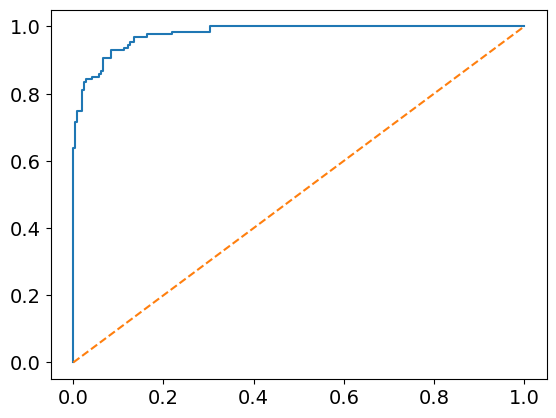

In [46]:
fpr,tpr,_ = roc_curve(y_train, lg2.predict(x_train2))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.savefig('roc_curve.png')
plt.show();

In [47]:
accuracy_score(y_train, pred_train2)

0.9090909090909091

In [48]:
cm = confusion_matrix(y_train, pred_train2)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,110,17
Actual Negative,14,200


### Final Model Prediction on Test Data

In [49]:
x_test = x_test.drop(columns=['id',
                              'texture_se',
                              'concavity_se',
                              'area_se',
                              'dimension_se',
                              'symmetry_se',
                              'smoothness_se',
                              'points_se'], axis=1)

In [50]:
pred_test = np.round(lg2.predict(x_test))

In [51]:
cm = confusion_matrix(y_test, pred_test)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,76,9
Actual Negative,8,135


In [52]:
accuracy_score(y_test, pred_test)

0.9254385964912281

### Gaussian NB

In [53]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,points_worst,symmetry_worst,dimension_worst
0,87139402,B,12.32,12.39,78.85,464.1,0.10280,0.06981,0.03987,0.03700,...,13.50,15.64,86.97,549.1,0.1385,0.1266,0.12420,0.09391,0.2827,0.06771
1,8910251,B,10.60,18.95,69.28,346.4,0.09688,0.11470,0.06387,0.02642,...,11.88,22.94,78.28,424.8,0.1213,0.2515,0.19160,0.07926,0.2940,0.07587
2,905520,B,11.04,16.83,70.92,373.2,0.10770,0.07804,0.03046,0.02480,...,12.41,26.44,79.93,471.4,0.1369,0.1482,0.10670,0.07431,0.2998,0.07881
3,868871,B,11.28,13.39,73.00,384.8,0.11640,0.11360,0.04635,0.04796,...,11.92,15.77,76.53,434.0,0.1367,0.1822,0.08669,0.08611,0.2102,0.06784
4,9012568,B,15.19,13.21,97.65,711.8,0.07963,0.06934,0.03393,0.02657,...,16.20,15.73,104.50,819.1,0.1126,0.1737,0.13620,0.08178,0.2487,0.06766


In [55]:
df['diagnosis'].value_counts(1)*100

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

In [61]:
x_nb = df.drop(['diagnosis'],axis=1)
y_nb = df['diagnosis']
x_nb = pd.get_dummies(x_nb, drop_first=True).astype(int)
x_train, x_test, y_train, y_test = train_test_split(x_nb, y_nb, test_size = 0.37, stratify = y, random_state = 42)

In [62]:
model = GaussianNB()
model.fit(x_train, y_train.ravel())

GaussianNB()

In [63]:
pred_train = model.predict(x_train)

In [64]:
print(classification_report(y_train, pred_train))

              precision    recall  f1-score   support

           B       0.63      1.00      0.77       225
           M       0.75      0.02      0.04       133

    accuracy                           0.63       358
   macro avg       0.69      0.51      0.41       358
weighted avg       0.68      0.63      0.50       358



In [65]:
cm = confusion_matrix(y_train, pred_train)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,3,130
Actual Negative,1,224


### Prediction on test dataset

In [66]:
pred_test = model.predict(x_test)

In [67]:
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           B       0.62      0.96      0.76       132
           M       0.29      0.03      0.05        79

    accuracy                           0.61       211
   macro avg       0.45      0.49      0.40       211
weighted avg       0.50      0.61      0.49       211



In [69]:
cm = confusion_matrix(y_test, pred_test)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                       [cm[0,1],cm[0,0]]],
                      columns=['Predicted Positive','Predicted Negative'],
                      index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,2,77
Actual Negative,5,127
